In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

In [51]:
df_eda = pd.read_csv('F:/traffic-analysis-biratnagar/data/processed_data.csv')
print("Available columns:", df_eda.columns.tolist())
X = df_eda.drop(columns=['Severity'])
y = df_eda['Severity']

Available columns: ['Ward', 'Road_Type', 'No_of_vehicles_involved', 'Time_Range', 'Month_Num', 'Nepali_Season', 'Weather_Clear', 'Weather_Cold', 'Weather_Cool', 'Weather_Dry', 'Weather_Dusty', 'Weather_Foggy', 'Weather_Frosty', 'Weather_Hot', 'Weather_Humid', 'Weather_Mild', 'Weather_Overcast', 'Weather_Pleasant', 'Weather_Rainy', 'Weather_Thunderstorm', 'Weather_Warm', 'Weather_Windy', 'Severity', 'Ward_Location_Risk']


In [52]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("=== Split Sizes ===")
print(f"Train : {X_train.shape[0]} rows | High={y_train.sum()} Low={( y_train==0).sum()}")
print(f"Val   : {X_val.shape[0]} rows | High={y_val.sum()} Low={(y_val==0).sum()}")
print(f"Test  : {X_test.shape[0]} rows | High={y_test.sum()} Low={(y_test==0).sum()}")

=== Split Sizes ===
Train : 638 rows | High=49 Low=589
Val   : 137 rows | High=11 Low=126
Test  : 137 rows | High=10 Low=127


In [53]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',   # handles class imbalance
    random_state=42,
    n_jobs=-1
)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=(y_train == 0).sum() / y_train.sum(),  # handles imbalance
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [54]:
def evaluate_model(model, X, y, model_name, split_name):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    f1     = f1_score(y, y_pred)
    roc    = roc_auc_score(y, y_prob)
    print(f"\n{'='*50}")
    print(f"{model_name} — {split_name}")
    print(f"{'='*50}")
    print(classification_report(y, y_pred, target_names=['Low', 'High']))
    print(f"F1 Score : {f1:.4f}")
    print(f"ROC-AUC  : {roc:.4f}")
    return f1, roc, y_pred, y_prob

In [55]:
# Validation scores
rf_val_f1,  rf_val_roc,  _, _ = evaluate_model(rf,  X_val, y_val, "Random Forest", "Validation")
xgb_val_f1, xgb_val_roc, _, _ = evaluate_model(xgb, X_val, y_val, "XGBoost",       "Validation")

# Test scores
rf_test_f1,  rf_test_roc,  rf_test_pred,  rf_test_prob  = evaluate_model(rf,  X_test, y_test, "Random Forest", "Test")
xgb_test_f1, xgb_test_roc, xgb_test_pred, xgb_test_prob = evaluate_model(xgb, X_test, y_test, "XGBoost",       "Test")


Random Forest — Validation
              precision    recall  f1-score   support

         Low       0.92      0.98      0.95       126
        High       0.00      0.00      0.00        11

    accuracy                           0.91       137
   macro avg       0.46      0.49      0.48       137
weighted avg       0.84      0.91      0.87       137

F1 Score : 0.0000
ROC-AUC  : 0.7388

XGBoost — Validation
              precision    recall  f1-score   support

         Low       0.93      0.91      0.92       126
        High       0.15      0.18      0.17        11

    accuracy                           0.85       137
   macro avg       0.54      0.55      0.54       137
weighted avg       0.87      0.85      0.86       137

F1 Score : 0.1667
ROC-AUC  : 0.6551

Random Forest — Test
              precision    recall  f1-score   support

         Low       0.92      0.97      0.95       127
        High       0.00      0.00      0.00        10

    accuracy                          

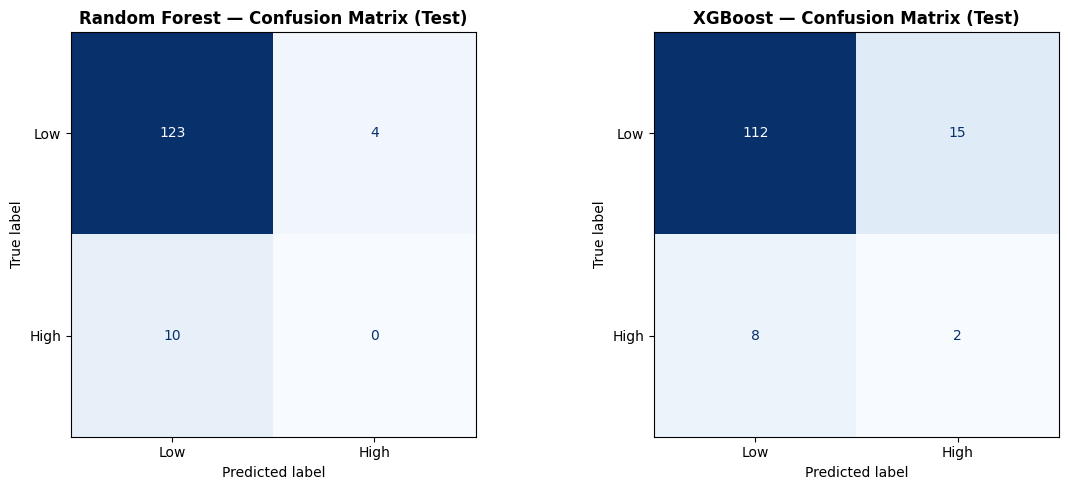

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in zip(axes,
                            [rf_test_pred, xgb_test_pred],
                            ['Random Forest', 'XGBoost']):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'High'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title} — Confusion Matrix (Test)', fontweight='bold')

plt.tight_layout()
plt.show()

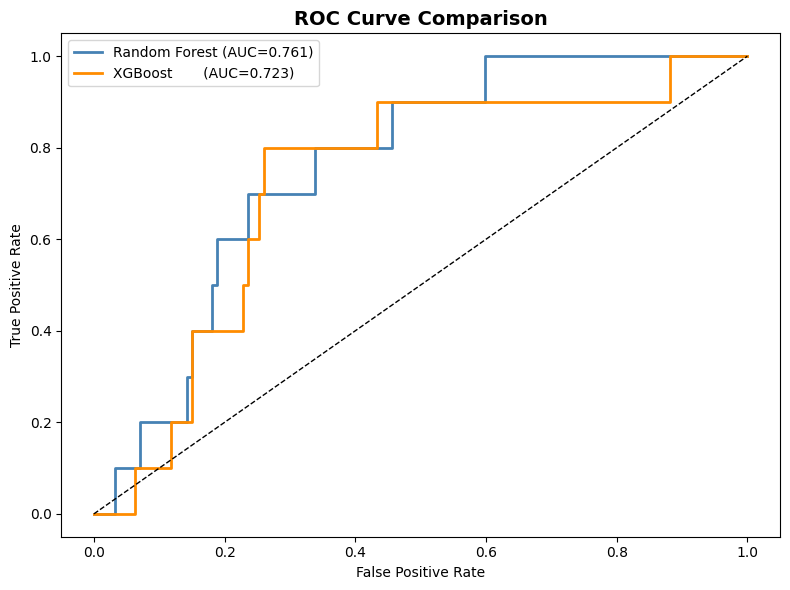

In [57]:
fig, ax = plt.subplots(figsize=(8, 6))

for prob, label, color in [
    (rf_test_prob,  f'Random Forest (AUC={rf_test_roc:.3f})',  'steelblue'),
    (xgb_test_prob, f'XGBoost       (AUC={xgb_test_roc:.3f})', 'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, label=label, linewidth=2, color=color)

ax.plot([0,1],[0,1], 'k--', linewidth=1)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

In [58]:
comparison = pd.DataFrame({
    'Model'   : ['Random Forest', 'XGBoost'],
    'Val F1'  : [rf_val_f1,  xgb_val_f1],
    'Test F1' : [rf_test_f1, xgb_test_f1],
    'Val AUC' : [rf_val_roc,  xgb_val_roc],
    'Test AUC': [rf_test_roc, xgb_test_roc]
}).round(4)

print("\n=== Model Comparison ===")
print(comparison.to_string(index=False))

best_model_name = 'XGBoost' if xgb_test_f1 >= rf_test_f1 else 'Random Forest'
best_model      = xgb       if xgb_test_f1 >= rf_test_f1 else rf
print(f"\n✅ Best Model: {best_model_name}")


=== Model Comparison ===
        Model  Val F1  Test F1  Val AUC  Test AUC
Random Forest  0.0000   0.0000   0.7388    0.7606
      XGBoost  0.1667   0.1481   0.6551    0.7228

✅ Best Model: XGBoost


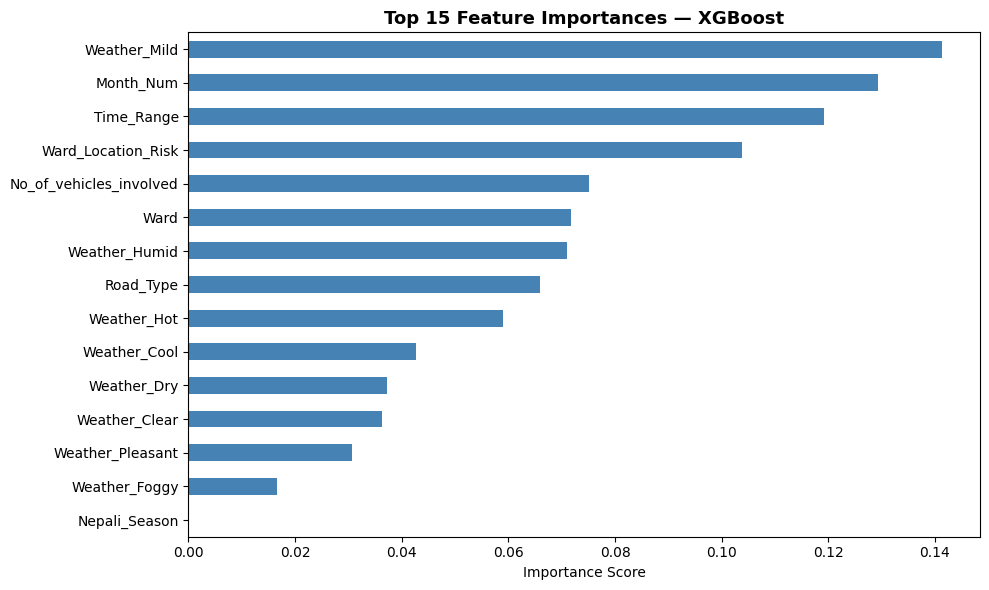

In [59]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top 15 Feature Importances — {best_model_name}', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [60]:
# ─────────────────────────────────────────────
def predict_severity_profile(ward, road_type, time_range, month_num,
                              nepali_season, n_vehicles=2,
                              weather_col='Weather_Clear'):

    # Look up risk from saved mapping (Ward only, since Location is dropped)
    ward_risk = ward_location_risk_map.get(
        ward,
        np.mean(list(ward_location_risk_map.values()))  # fallback to mean
    )
    row = pd.DataFrame([{col: 0 for col in X.columns}])
    row['Ward']                      = ward
    row['Road_Type']                 = road_type
    row['No_of_vehicles_involved']   = n_vehicles
    row['Time_Range']                = time_range
    row['Month_Num']                 = month_num
    row['Nepali_Season']             = nepali_season
    row[weather_col]                 = 1

    prob_high = xgb.predict_proba(row)[0][1]
    prob_low  = 1 - prob_high

    print(f"\n{'='*55}")
    print(f"  Severity Prediction Profile")
    print(f"{'='*55}")
    print(f"  Ward                : {ward}")
    print(f"  Risk Score (Severity): {ward_risk:.4f}")
    print(f"  Road Type           : {road_type}  |  Vehicles : {n_vehicles}")
    print(f"  Time Range          : {time_range}  |  Month    : {month_num}")
    print(f"  Nepali Season       : {nepali_season}  |  Weather  : {weather_col}")
    print(f"{'─'*55}")
    print(f"  🟢 Low  Severity Probability  : {prob_low*100:.1f}%")
    print(f"  🔴 High Severity Probability  : {prob_high*100:.1f}%")
    print(f"  📊 Risk Level : {'HIGH ⚠️' if prob_high >= 0.5 else 'LOW ✅'}")
    print(f"{'='*55}")

    return {'ward': ward, 'prob_low': prob_low, 'prob_high': prob_high}

In [61]:
# Location column is also dropped, so create risk map by Ward only
df_temp = df_eda.copy()

# Create ward_location_risk_map based on Ward (since Location is also dropped)
ward_location_risk_map = df_temp.groupby('Ward')['Severity'].mean().to_dict()

print("Ward Risk Map created:")
print(f"Total wards: {len(ward_location_risk_map)}")
print(f"Sample: {dict(list(ward_location_risk_map.items())[:5])}")

Ward Risk Map created:
Total wards: 19
Sample: {1: 0.06060606060606061, 2: 0.07142857142857142, 3: 0.1792452830188679, 4: 0.0784313725490196, 5: 0.06896551724137931}


In [62]:
def ward_location_risk_report(time_range, month_num, nepali_season,
                               weather_col='Weather_Clear', road_type=1, n_vehicles=2):

    records = []
    for ward in sorted(ward_location_risk_map.keys()):
        r = predict_severity_profile(ward, road_type, time_range,
                                     month_num, nepali_season, n_vehicles, weather_col)
        records.append({
            'Ward'                : ward,
            'High_Severity_%'     : round(r['prob_high'] * 100, 1),
            'Low_Severity_%'      : round(r['prob_low']  * 100, 1),
            'Risk_Level'          : 'HIGH ⚠️' if r['prob_high'] >= 0.5 else 'LOW ✅'
        })
    report = pd.DataFrame(records).sort_values('High_Severity_%', ascending=False)

    fig, ax = plt.subplots(figsize=(14, 6))
    colors = ['red' if r == 'HIGH ⚠️' else 'green' for r in report['Risk_Level']]
    ax.bar(report['Ward'].astype(str), report['High_Severity_%'], color=colors)
    ax.axhline(50, color='black', linestyle='--', linewidth=1, label='50% threshold')
    ax.set_title(
        f'High Severity Risk % by Ward\n'
        f'(Time={time_range}, Month={month_num}, Season={nepali_season}, Weather={weather_col})',
        fontweight='bold'
    )
    ax.set_xlabel('Ward')
    ax.set_ylabel('High Severity Probability (%)')
    ax.tick_params(axis='x', rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

    print("\n=== Ward Risk Report ===")
    print(report.to_string(index=False))
    return report

In [63]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X_train, y_train, cv=cv, scoring='f1')

print("\n=== 5-Fold Cross Validation — XGBoost ===")
print(f"  F1 per fold : {[round(s, 4) for s in cv_scores]}")
print(f"  Mean F1     : {cv_scores.mean():.4f}")
print(f"  Std F1      : {cv_scores.std():.4f}")


=== 5-Fold Cross Validation — XGBoost ===
  F1 per fold : [np.float64(0.0909), np.float64(0.0), np.float64(0.2), np.float64(0.0833), np.float64(0.0667)]
  Mean F1     : 0.0882
  Std F1      : 0.0645


In [64]:
result = predict_severity_profile(
    ward=15,
    road_type=1,
    time_range=2,
    month_num=4,
    nepali_season=2,
    n_vehicles=2,
    weather_col='Weather_Rainy'
)


  Severity Prediction Profile
  Ward                : 15
  Risk Score (Severity): 0.0469
  Road Type           : 1  |  Vehicles : 2
  Time Range          : 2  |  Month    : 4
  Nepali Season       : 2  |  Weather  : Weather_Rainy
───────────────────────────────────────────────────────
  🟢 Low  Severity Probability  : 98.1%
  🔴 High Severity Probability  : 1.9%
  📊 Risk Level : LOW ✅



  Severity Prediction Profile
  Ward                : 1
  Risk Score (Severity): 0.0606
  Road Type           : 1  |  Vehicles : 2
  Time Range          : 2  |  Month    : 4
  Nepali Season       : 2  |  Weather  : Weather_Rainy
───────────────────────────────────────────────────────
  🟢 Low  Severity Probability  : 26.1%
  🔴 High Severity Probability  : 73.9%
  📊 Risk Level : HIGH ⚠️

  Severity Prediction Profile
  Ward                : 2
  Risk Score (Severity): 0.0714
  Road Type           : 1  |  Vehicles : 2
  Time Range          : 2  |  Month    : 4
  Nepali Season       : 2  |  Weather  : Weather_Rainy
───────────────────────────────────────────────────────
  🟢 Low  Severity Probability  : 23.4%
  🔴 High Severity Probability  : 76.6%
  📊 Risk Level : HIGH ⚠️

  Severity Prediction Profile
  Ward                : 3
  Risk Score (Severity): 0.1792
  Road Type           : 1  |  Vehicles : 2
  Time Range          : 2  |  Month    : 4
  Nepali Season       : 2  |  Weather  : Weathe

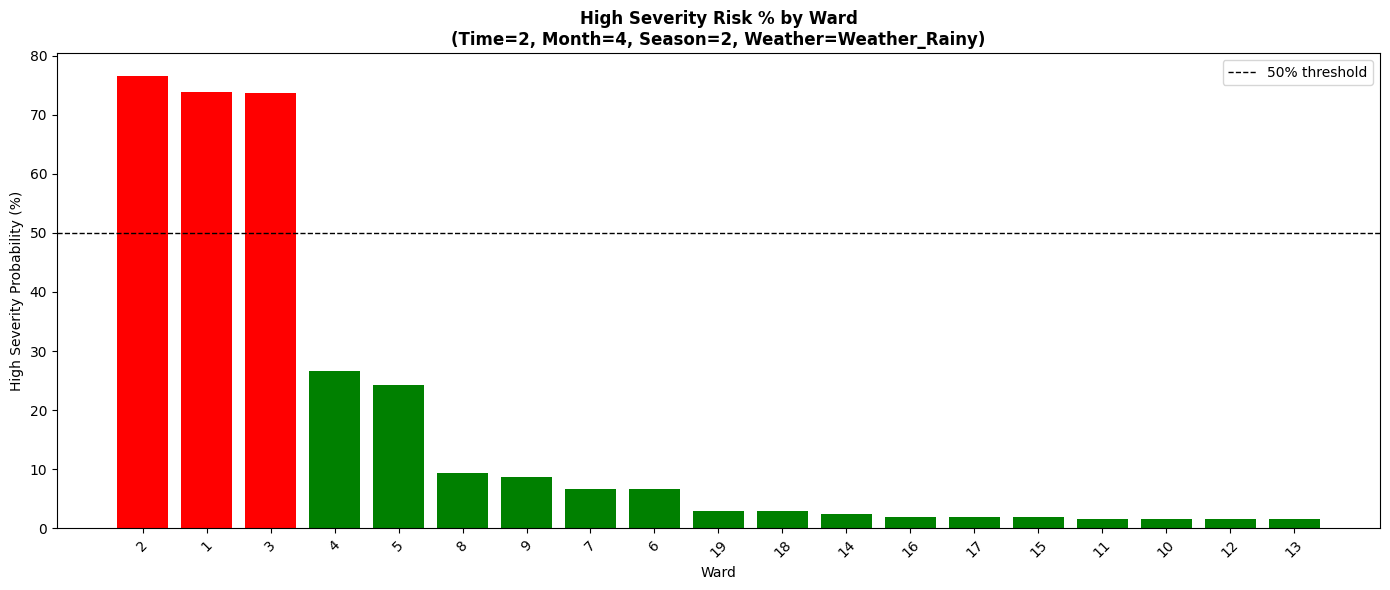


=== Ward Risk Report ===
 Ward  High_Severity_%  Low_Severity_% Risk_Level
    2        76.599998       23.400000    HIGH ⚠️
    1        73.900002       26.100000    HIGH ⚠️
    3        73.699997       26.299999    HIGH ⚠️
    4        26.700001       73.300003      LOW ✅
    5        24.200001       75.800003      LOW ✅
    8         9.400000       90.599998      LOW ✅
    9         8.700000       91.300003      LOW ✅
    7         6.700000       93.300003      LOW ✅
    6         6.700000       93.300003      LOW ✅
   19         3.000000       97.000000      LOW ✅
   18         3.000000       97.000000      LOW ✅
   14         2.400000       97.599998      LOW ✅
   16         1.900000       98.099998      LOW ✅
   17         1.900000       98.099998      LOW ✅
   15         1.900000       98.099998      LOW ✅
   11         1.600000       98.400002      LOW ✅
   10         1.600000       98.400002      LOW ✅
   12         1.500000       98.500000      LOW ✅
   13         1.500000  

In [65]:
ward_report = ward_location_risk_report(
    time_range=2,
    month_num=4,
    nepali_season=2,
    weather_col='Weather_Rainy'
)

# See all available wards in your data
print("\nAvailable Wards:")
for ward in sorted(ward_location_risk_map.keys()):
    print(f"  Ward {ward}  →  avg_severity={ward_location_risk_map[ward]:.4f}")

In [66]:
# ═════════════════════════════════════════════════════════════════
# PART 2: WARD-LOCATION RISK ANALYSIS (with Time Range)
# ═════════════════════════════════════════════════════════════════

# Load cleaned data with original Ward + Location columns
df_clean = pd.read_csv('F:/traffic-analysis-biratnagar/data/cleaned_data.csv')

# Create ward_location concatenation with SPACE instead of underscore
df_clean['Ward_Location'] = df_clean['Ward'].astype(str) + ' ' + df_clean['Location']

# Map severity to binary (high/medium=1, low=0)
# Merging medium and high severity into single "high severity" category
df_clean['Severity_Binary'] = (df_clean['Severity'].isin(['high', 'medium'])).astype(int)

print("✓ Cleaned data loaded with Ward_Location concatenation (space-separated)")
print(f"  Total ward-location combinations: {df_clean['Ward_Location'].nunique()}")
print(f"  Sample combinations: {df_clean['Ward_Location'].unique()[:10]}")
print(f"\n  Severity distribution: \n{df_clean['Severity'].value_counts()}")

✓ Cleaned data loaded with Ward_Location concatenation (space-separated)
  Total ward-location combinations: 262
  Sample combinations: <StringArray>
[        '4 oil nigam',   '12 roadcess chowk',   '4 rajbanshi chowk',
             '13 rani',             '18 rani',  '19 pushpalal chowk',
      '7 danphe chowk', '8 bishwakarma chowk',        '1 neta chowk',
            '4 ikrahi']
Length: 10, dtype: str

  Severity distribution: 
Severity
low       842
medium     42
high       29
Name: count, dtype: int64


In [67]:
# Create risk maps by Ward-Location
ward_location_risk_map_v2 = df_clean.groupby('Ward_Location')['Severity_Binary'].mean().to_dict()

# Risk maps by (Ward_Location, Month)
month_ward_location_risk_map = df_clean.groupby(['Ward_Location', 'Month_Num'])['Severity_Binary'].mean().to_dict()

# Risk maps by (Ward_Location, Time_Range)
time_ward_location_risk_map = df_clean.groupby(['Ward_Location', 'Time_Range'])['Severity_Binary'].mean().to_dict()

# Combined: (Ward_Location, Month, Time_Range, Road_Type)
combined_risk_map = df_clean.groupby(['Ward_Location', 'Month_Num', 'Time_Range', 'Road_Type'])['Severity_Binary'].mean().to_dict()

print("✓ Risk maps created:")
print(f"  Ward-Location Risk Map: {len(ward_location_risk_map_v2)} unique combinations")
print(f"  Month × Ward-Location: {len(month_ward_location_risk_map)} entries")
print(f"  Time_Range × Ward-Location: {len(time_ward_location_risk_map)} entries")
print(f"  Combined (Ward-Location, Month, Time_Range, Road_Type): {len(combined_risk_map)} entries")
print(f"\n  Sample Ward-Location combinations (top 10 by risk):")
top_risks = sorted(ward_location_risk_map_v2.items(), key=lambda x: x[1], reverse=True)[:10]
for wl, risk in top_risks:
    print(f"    {wl:40s} → {risk:.4f}")

✓ Risk maps created:
  Ward-Location Risk Map: 262 unique combinations
  Month × Ward-Location: 563 entries
  Time_Range × Ward-Location: 400 entries
  Combined (Ward-Location, Month, Time_Range, Road_Type): 771 entries

  Sample Ward-Location combinations (top 10 by risk):
    1 bhatta chowk                           → 1.0000
    1 mahespur                               → 1.0000
    10 jahada road                           → 1.0000
    13 rice mill                             → 1.0000
    14 hamro hospital                        → 1.0000
    14 plastic factory                       → 1.0000
    2 hanuman mandir                         → 1.0000
    3 football chowk                         → 1.0000
    3 tirupati petrol pump                   → 1.0000
    4 chadani chowk                          → 1.0000


In [68]:
# ══════════════════════════════════════════════════════════════════
# COMPREHENSIVE ANALYSIS FUNCTION
# User provides: ward, location, month, time_range, road_type
# ══════════════════════════════════════════════════════════════════

def analyze_accident_severity(ward, location, month, time_range, road_type, nepali_season):
    """
    Comprehensive analysis for a specific ward-location-month-time combination.
    
    Inputs:
    - ward: Ward number (e.g., 15)
    - location: Location name (e.g., 'rani')
    - month: Month number (e.g., 4)
    - time_range: Time range (0-3 typically: 0=00:00-06:00, 1=06:00-12:00, 2=12:00-18:00, 3=18:00-00:00)
    - road_type: Road type (0 or 1 typically)
    - nepali_season: Nepali season (1-4 typically)
    
    Performs:
    1. EDA on filtered historical data
    2. Severity breakdown analysis (Medium + High merged as HIGH)
    3. ML model prediction
    4. Comparison of high vs low severity accidents
    """
    
    ward_location = f"{ward} {location}"
    
    # ──────────────────────────────────────────────────────────
    # STEP 1: EDA - Filter and analyze historical data
    # ──────────────────────────────────────────────────────────
    
    # Filter data by all criteria
    filtered_data = df_clean[
        (df_clean['Ward'] == ward) &
        (df_clean['Location'].str.lower() == location.lower()) &
        (df_clean['Month_Num'] == month) &
        (df_clean['Time_Range'] == time_range) &
        (df_clean['Road_Type'] == road_type)
    ]
    
    # Also get broader context (same ward-location-month, any time)
    broader_data = df_clean[
        (df_clean['Ward'] == ward) &
        (df_clean['Location'].str.lower() == location.lower()) &
        (df_clean['Month_Num'] == month)
    ]
    
    # Even broader: same ward-location, any month
    location_data = df_clean[
        (df_clean['Ward'] == ward) &
        (df_clean['Location'].str.lower() == location.lower())
    ]
    
    print("\n" + "═"*80)
    print(f"  🔍 ACCIDENT SEVERITY ANALYSIS FOR: {ward_location}")
    print("═"*80)
    print(f"\n📍 Query Parameters:")
    print(f"   Ward: {ward} | Location: {location}")
    print(f"   Month: {month} | Time Range: {time_range} | Road Type: {road_type}")
    print(f"   Nepali Season: {nepali_season}")
    
    # ──────────────────────────────────────────────────────────
    # STEP 2: Severity Analysis
    # (Merging MEDIUM + HIGH into HIGH category)
    # ──────────────────────────────────────────────────────────
    
    print(f"\n" + "─"*80)
    print(f"📊 SEVERITY BREAKDOWN (Medium + High merged as HIGH)")
    print("─"*80)
    
    if len(filtered_data) > 0:
        print(f"\n✓ Found {len(filtered_data)} accident(s) in THIS exact scenario (M={month}, T={time_range}):")
        # Merge medium and high into one category
        severity_counts_merged = filtered_data['Severity'].apply(
            lambda x: 'HIGH' if x in ['high', 'medium'] else 'LOW'
        ).value_counts()
        severity_pct_merged = (filtered_data['Severity'].apply(
            lambda x: 'HIGH' if x in ['high', 'medium'] else 'LOW'
        ).value_counts(normalize=True) * 100).round(1)
        
        for sev in ['LOW', 'HIGH (includes Medium)']:
            count = severity_counts_merged.get(sev, 0)
            pct = severity_pct_merged.get(sev, 0)
            print(f"   {sev:20s}: {count:2d} accidents ({pct:5.1f}%)")
        
        high_sev_direct = (filtered_data['Severity'].isin(['high', 'medium'])).sum()
        low_sev_direct = (filtered_data['Severity'] == 'low').sum()
    else:
        print(f"\n⚠️  No accidents found in THIS exact scenario.")
        print(f"   Using broader data for context...")
        high_sev_direct = 0
        low_sev_direct = 0
    
    if len(broader_data) > 0:
        print(f"\n✓ In SAME WARD-LOCATION-MONTH (any time): {len(broader_data)} accidents")
        severity_counts_b_merged = broader_data['Severity'].apply(
            lambda x: 'HIGH' if x in ['high', 'medium'] else 'LOW'
        ).value_counts()
        severity_pct_b_merged = (broader_data['Severity'].apply(
            lambda x: 'HIGH' if x in ['high', 'medium'] else 'LOW'
        ).value_counts(normalize=True) * 100).round(1)
        
        for sev in ['LOW', 'HIGH']:
            count = severity_counts_b_merged.get(sev, 0)
            pct = severity_pct_b_merged.get(sev, 0)
            print(f"   {sev:20s}: {count:2d} accidents ({pct:5.1f}%)")
        
        high_sev_broader = (broader_data['Severity'].isin(['high', 'medium'])).sum()
        low_sev_broader = (broader_data['Severity'] == 'low').sum()
        high_sev_pct_broader = (high_sev_broader / len(broader_data) * 100) if len(broader_data) > 0 else 0
    else:
        high_sev_broader = 0
        low_sev_broader = 0
        high_sev_pct_broader = 0
    
    if len(location_data) > 0:
        print(f"\n✓ In SAME WARD-LOCATION (all months): {len(location_data)} accidents")
        severity_counts_l_merged = location_data['Severity'].apply(
            lambda x: 'HIGH' if x in ['high', 'medium'] else 'LOW'
        ).value_counts()
        severity_pct_l_merged = (location_data['Severity'].apply(
            lambda x: 'HIGH' if x in ['high', 'medium'] else 'LOW'
        ).value_counts(normalize=True) * 100).round(1)
        
        for sev in ['LOW', 'HIGH']:
            count = severity_counts_l_merged.get(sev, 0)
            pct = severity_pct_l_merged.get(sev, 0)
            print(f"   {sev:20s}: {count:2d} accidents ({pct:5.1f}%)")
        
        high_sev_location = (location_data['Severity'].isin(['high', 'medium'])).sum()
        low_sev_location = (location_data['Severity'] == 'low').sum()
        high_sev_pct_location = (high_sev_location / len(location_data) * 100) if len(location_data) > 0 else 0
    else:
        high_sev_location = 0
        low_sev_location = 0
        high_sev_pct_location = 0
    
    # ──────────────────────────────────────────────────────────
    # STEP 3: ML Model Prediction
    # ──────────────────────────────────────────────────────────
    
    print(f"\n" + "─"*80)
    print(f"🤖 ML MODEL PREDICTION")
    print("─"*80)
    
    # Create feature row (only using: Ward, Road_Type, Time_Range, Month_Num, Nepali_Season)
    # NOT using: vehicles, weather
    row = pd.DataFrame([{col: 0 for col in X.columns}])
    row['Ward'] = ward
    row['Road_Type'] = road_type
    row['Time_Range'] = time_range
    row['Month_Num'] = month
    row['Nepali_Season'] = nepali_season
    # Set first weather to default (doesn't affect since we're not using multiple weather cols)
    row['Weather_Clear'] = 1
    
    # Get XGBoost prediction
    prob_high = xgb.predict_proba(row)[0][1]
    prob_low = 1 - prob_high
    
    print(f"\n  Based on features (Ward, Road_Type, Time_Range, Month, Season):")
    print(f"  🟢 Low Severity Probability:        {prob_low*100:6.2f}%")
    print(f"  🔴 High Severity Probability:       {prob_high*100:6.2f}%")
    
    # ──────────────────────────────────────────────────────────
    # STEP 4: Severity Comparison & Prediction
    # ──────────────────────────────────────────────────────────
    
    print(f"\n" + "─"*80)
    print(f"⚠️  SEVERITY PREDICTION & COMPARISON")
    print("─"*80)
    
    # Determine most likely severity
    if prob_high >= 0.5:
        prediction = "HIGH SEVERITY ⚠️ "
        color_pred = "🔴"
    else:
        prediction = "LOW SEVERITY ✅"
        color_pred = "🟢"
    
    print(f"\n  {color_pred} Model Prediction: {prediction}")
    print(f"\n  Analysis based on historical data:")
    
    if high_sev_pct_broader > 0:
        print(f"    → High severity  accidents in this month: {high_sev_pct_broader:.1f}%")
        print(f"    → Low severity accidents: {100-high_sev_pct_broader:.1f}%")
        
        if high_sev_pct_broader > 50:
            print(f"    ⚠️  CONCLUSION: More HIGH severity accidents occur in {ward_location}")
        else:
            print(f"    ✅ CONCLUSION: More LOW severity accidents occur in {ward_location}")
    else:
        print(f"    → No historical data for direct comparison")
        print(f"    → Using model prediction: {prediction}")
    
    print(f"\n" + "="*80)
    
    return {
        'ward_location': ward_location,
        'filtered_count': len(filtered_data),
        'broader_count': len(broader_data),
        'location_count': len(location_data),
        'high_sev_pct_broader': high_sev_pct_broader,
        'prob_high_model': prob_high,
        'prediction': prediction
    }

print("✓ Function defined: analyze_accident_severity()")

✓ Function defined: analyze_accident_severity()


In [69]:
# ══════════════════════════════════════════════════════════════════
# EXAMPLE 1: Analyze Ward 15, Location 'rani', Month 4, Time 2, Road 1
# ══════════════════════════════════════════════════════════════════

result1 = analyze_accident_severity(
    ward=15,
    location='rani',
    month=4,
    time_range=2,         # 12:00-18:00
    road_type=1,
    nepali_season=2
)


════════════════════════════════════════════════════════════════════════════════
  🔍 ACCIDENT SEVERITY ANALYSIS FOR: 15 rani
════════════════════════════════════════════════════════════════════════════════

📍 Query Parameters:
   Ward: 15 | Location: rani
   Month: 4 | Time Range: 2 | Road Type: 1
   Nepali Season: 2

────────────────────────────────────────────────────────────────────────────────
📊 SEVERITY BREAKDOWN (Medium + High merged as HIGH)
────────────────────────────────────────────────────────────────────────────────

⚠️  No accidents found in THIS exact scenario.
   Using broader data for context...

✓ In SAME WARD-LOCATION-MONTH (any time): 5 accidents
   LOW                 :  5 accidents (100.0%)
   HIGH                :  0 accidents (  0.0%)

✓ In SAME WARD-LOCATION (all months): 41 accidents
   LOW                 : 40 accidents ( 97.6%)
   HIGH                :  1 accidents (  2.4%)

────────────────────────────────────────────────────────────────────────────────
🤖 M

In [70]:
# ══════════════════════════════════════════════════════════════════
# EXAMPLE 2: Analyze Ward 4, Location 'oil nigam', Month 4, Time 1, Road 0
# ══════════════════════════════════════════════════════════════════

result2 = analyze_accident_severity(
    ward=4,
    location='oil nigam',
    month=4,
    time_range=1,         # 06:00-12:00
    road_type=0,
    nepali_season=2
)


════════════════════════════════════════════════════════════════════════════════
  🔍 ACCIDENT SEVERITY ANALYSIS FOR: 4 oil nigam
════════════════════════════════════════════════════════════════════════════════

📍 Query Parameters:
   Ward: 4 | Location: oil nigam
   Month: 4 | Time Range: 1 | Road Type: 0
   Nepali Season: 2

────────────────────────────────────────────────────────────────────────────────
📊 SEVERITY BREAKDOWN (Medium + High merged as HIGH)
────────────────────────────────────────────────────────────────────────────────

⚠️  No accidents found in THIS exact scenario.
   Using broader data for context...

✓ In SAME WARD-LOCATION-MONTH (any time): 4 accidents
   LOW                 :  3 accidents ( 75.0%)
   HIGH                :  1 accidents ( 25.0%)

✓ In SAME WARD-LOCATION (all months): 32 accidents
   LOW                 : 30 accidents ( 93.8%)
   HIGH                :  2 accidents (  6.2%)

────────────────────────────────────────────────────────────────────────────

In [71]:
# ══════════════════════════════════════════════════════════════════
# EXAMPLE 3: Analyze Ward 14, Location 'rani', Month 5, Time 3, Road 1
# ══════════════════════════════════════════════════════════════════

result3 = analyze_accident_severity(
    ward=14,
    location='rani',
    month=5,
    time_range=3,         # 18:00-00:00
    road_type=1,
    nepali_season=2
)


════════════════════════════════════════════════════════════════════════════════
  🔍 ACCIDENT SEVERITY ANALYSIS FOR: 14 rani
════════════════════════════════════════════════════════════════════════════════

📍 Query Parameters:
   Ward: 14 | Location: rani
   Month: 5 | Time Range: 3 | Road Type: 1
   Nepali Season: 2

────────────────────────────────────────────────────────────────────────────────
📊 SEVERITY BREAKDOWN (Medium + High merged as HIGH)
────────────────────────────────────────────────────────────────────────────────

⚠️  No accidents found in THIS exact scenario.
   Using broader data for context...

✓ In SAME WARD-LOCATION-MONTH (any time): 4 accidents
   LOW                 :  3 accidents ( 75.0%)
   HIGH                :  1 accidents ( 25.0%)

✓ In SAME WARD-LOCATION (all months): 77 accidents
   LOW                 : 73 accidents ( 94.8%)
   HIGH                :  4 accidents (  5.2%)

────────────────────────────────────────────────────────────────────────────────
🤖 M

In [72]:
# ══════════════════════════════════════════════════════════════════
# REFERENCE: Available Values for Queries
# ══════════════════════════════════════════════════════════════════

print("\n" + "█"*80)
print("█" + " "*78 + "█")
print("█" + "  REFERENCE: AVAILABLE VALUES FOR ANALYSIS".center(78) + "█")
print("█" + " "*78 + "█")
print("█"*80)

print(f"\n🏘️  WARDS ({len(df_clean['Ward'].unique())} total):")
print(f"   {sorted(df_clean['Ward'].unique().tolist())}")

print(f"\n📍 LOCATIONS ({len(df_clean['Location'].unique())} total):")
locations_by_count = df_clean['Location'].value_counts().sort_values(ascending=False)
print(f"   Top 20 locations:")
for i, (loc, count) in enumerate(locations_by_count.head(20).items(), 1):
    print(f"      {i:2d}. {loc:35s} ({count:3d} accidents)")

print(f"\n📅 MONTHS (1-12, Nepali calendar):")
for m in sorted(df_clean['Month_Num'].unique()):
    count = len(df_clean[df_clean['Month_Num'] == m])
    print(f"   Month {m:2d}: {count:3d} accidents")

print(f"\n⏰ TIME RANGES:")
time_labels = {0: '00:00-06:00', 1: '06:00-12:00', 2: '12:00-18:00', 3: '18:00-00:00'}
for tr in sorted(df_clean['Time_Range'].unique()):
    count = len(df_clean[df_clean['Time_Range'] == tr])
    print(f"   {tr} ({time_labels.get(tr, 'unknown'):12s}): {count:3d} accidents")

print(f"\n🛣️  ROAD TYPES:")
for rt in sorted(df_clean['Road_Type'].unique()):
    count = len(df_clean[df_clean['Road_Type'] == rt])
    print(f"   Road Type {rt}: {count:3d} accidents")

print(f"\n🌦️  NEPALI SEASONS:")
season_labels = {1: 'Spring', 2: 'Summer', 3: 'Autumn', 4: 'Winter'}
for ns in sorted(df_clean['Nepali_Season'].unique()):
    count = len(df_clean[df_clean['Nepali_Season'] == ns])
    label = season_labels.get(ns, 'Unknown')
    print(f"   Season {ns} ({label:10s}): {count:3d} accidents")

print(f"\n{'█'*80}")


████████████████████████████████████████████████████████████████████████████████
█                                                                              █
█                    REFERENCE: AVAILABLE VALUES FOR ANALYSIS                  █
█                                                                              █
████████████████████████████████████████████████████████████████████████████████

🏘️  WARDS (19 total):
   [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]

📍 LOCATIONS (161 total):
   Top 20 locations:
       1. rani                                (263 accidents)
       2. dto                                 (113 accidents)
       3. oil nigam                           ( 56 accidents)
       4. hatkhola                            ( 53 accidents)
       5. pushpalal chowk                     ( 37 accidents)
       6. pipal chowk                         ( 20 accidents)
       7. kanchanbari                         ( 18 accidents)
       8. bargachhi

In [73]:
import joblib
import json
import os

# ── Save all artifacts in same folder as ml_module.ipynb ──
joblib.dump(xgb, 'xgb_model.pkl')

with open('ward_location_risk_map.json', 'w') as f:
    json.dump(ward_location_risk_map, f)

with open('feature_columns.json', 'w') as f:
    json.dump(list(X.columns), f)

df_eda.to_csv('df_eda.csv', index=False)

print("✅ Done — 4 files saved next to ml_module.ipynb:")
print("   xgb_model.pkl")
print("   ward_location_risk_map.json")
print("   feature_columns.json")
print("   df_eda.csv")

✅ Done — 4 files saved next to ml_module.ipynb:
   xgb_model.pkl
   ward_location_risk_map.json
   feature_columns.json
   df_eda.csv
